/tmp/ipykernel_630/749508664.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2019-01-01", end="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Données téléchargées : 252 lignes.
Price           Close       High        Low       Open     Volume
Date                                                             
2019-01-02  37.503723  37.724587  36.627401  36.784142  148158800
2019-01-03  33.768074  34.606398  33.722951  34.193172  365248800
2019-01-04  35.209606  35.278479  34.150423  34.323786  234428400
2019-01-07  35.131229  35.344969  34.649134  35.314094  219111200
2019-01-08  35.800949  36.055060  35.271357  35.518341  164101200

--- Résultats du Modèle ---
Erreur Quadratique Moyenne (MSE) : 0.64
Coefficient de détermination (R²) : 0.9914
Coeficients du modèle : [ 4.48645768e-02  4.56351959e-01  5.08035681e-01 -5.40080203e-11]
Ordonnée à l'origine : -0.24628976510632583


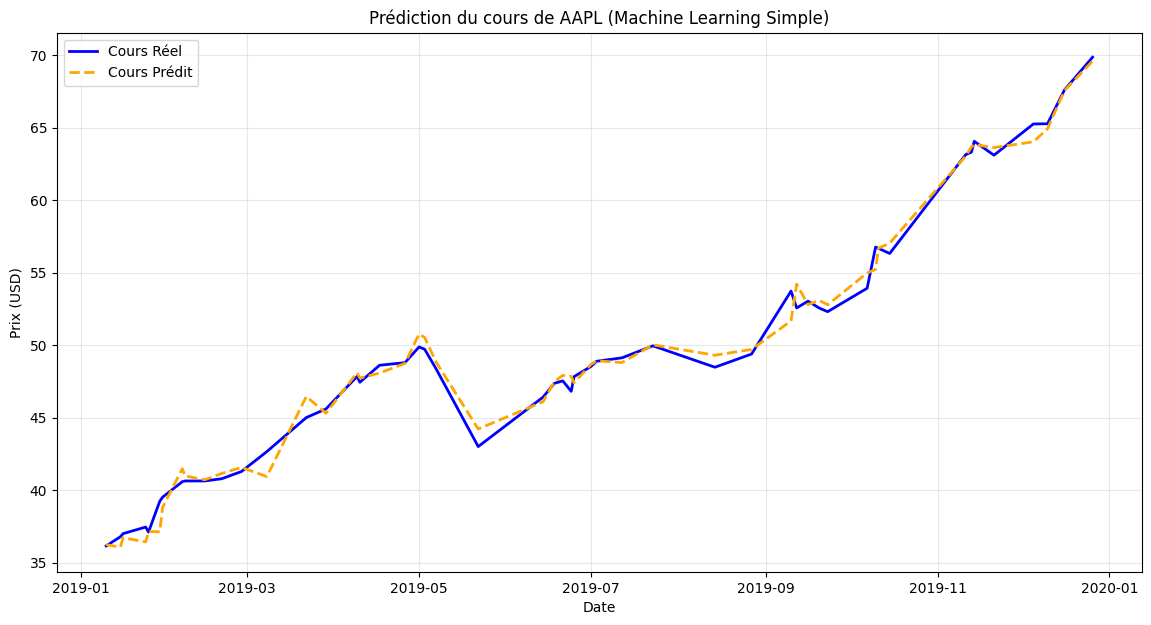

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. TÉLÉCHARGEMENT DES DONNÉES
# ---------------------------------------------------------
# On télécharge les données historiques de l'action Apple (AAPL)
# Période : 1er Janvier 2020 au 1er Janvier 2019
ticker = "AAPL"
data = yf.download(ticker, start="2019-01-01", end="2020-01-01")

# Gestion des colonnes (yfinance renvoie parfois un MultiIndex)
# Si les colonnes sont un tuple ('Close', 'AAPL'), on les aplatit
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# Vérification des données manquantes
data.dropna(inplace=True)

print(f"Données téléchargées : {len(data)} lignes.")
print(data.head())

# ---------------------------------------------------------
# 2. PRÉPARATION DES DONNÉES (FEATURE ENGINEERING)
# ---------------------------------------------------------
# On crée notre variable cible (Target) : le cours de clôture du JOUR SUIVANT
# On décale la colonne 'Close' de -1 vers le haut
data['Target'] = data['Close'].shift(-1)

# On supprime la dernière ligne car elle n'a pas de cible (futur inconnu)
data = data[:-1]

# Sélection des caractéristiques (Features) pour l'entraînement
# On utilise : Ouverture, Plus haut, Plus bas, Volume
features = ['Open', 'High', 'Low', 'Volume']
X = data[features]
y = data['Target']


# ---------------------------------------------------------
# 3. SÉPARATION ENTRAINEMENT / TEST
# ---------------------------------------------------------
# On sépare les données : 80% pour entraîner, 20% pour tester
# random_state=42 assure la reproductibilité du résultat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 4. ENTRAÎNEMENT DU MODÈLE
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. PRÉDICTION ET ÉVALUATION
# ---------------------------------------------------------
# On fait des prédictions sur l'ensemble de test
predictions = model.predict(X_test)

# Calcul des métriques de performance
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- Résultats du Modèle ---")
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.4f}")
print(f"Coeficients du modèle : {model.coef_}")
print(f"Ordonnée à l'origine : {model.intercept_}")

# ---------------------------------------------------------
# 6. VISUALISATION (GRAPHIQUE)
# ---------------------------------------------------------
# Pour le graphique, on aligne les index de temps
# On crée un DataFrame pour comparer facilement
results_df = pd.DataFrame({'Date': X_test.index, 'Réel': y_test, 'Prédit': predictions})
results_df.sort_index(inplace=True)

plt.figure(figsize=(14, 7))
plt.plot(results_df['Date'], results_df['Réel'], label='Cours Réel', color='blue', linewidth=2)
plt.plot(results_df['Date'], results_df['Prédit'], label='Cours Prédit', color='orange', linestyle='--', linewidth=2)

plt.title(f'Prédiction du cours de {ticker} (Machine Learning Simple)')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

# Sauvegarde optionnelle du graphique
# plt.savefig('prediction_aapl.png')

plt.show()